# Job Market Demand Forecasting Using LSTM

## Deep Learning Project — Time Series Forecasting

**Objective:** Forecast monthly job posting volume per occupational sector using an LSTM neural network trained on the Indeed Job Postings Index (US market).

**Dataset:** [Indeed Job Postings Index](https://www.kaggle.com/datasets/kimminh21/job-postings) — Daily seasonally-adjusted job postings index across 20+ occupational sectors, baseline = 100 on Feb 1, 2020.

**Why LSTM?** Unlike classical models (ARIMA, Prophet), LSTMs maintain hidden state across time steps, learning non-linear dependencies such as COVID-era shock-recovery patterns, regime changes, and multi-step seasonal cycles that linear models cannot capture.

---

### Notebook Structure
1. Environment Setup & Imports
2. Dataset Loading & Exploration
3. Initial Exploratory Data Analysis (EDA)
4. Monthly Aggregation Pipeline
5. Data Normalization & Sequence Generation
6. LSTM Model Architecture & Training
7. Evaluation (RMSE, MAE)
8. Future Forecasting & Visualization
9. Interpretation, Limitations & Improvements

## 1. Environment Setup & Imports

All libraries used are **pre-installed on Kaggle**. No `pip install` needed.

| Library | Purpose |
|---------|---------|
| `pandas` | Data manipulation, time-series resampling |
| `numpy` | Numerical operations |
| `matplotlib` / `seaborn` | Static visualizations (report-quality) |
| `sklearn.preprocessing` | MinMaxScaler for normalization |
| `tensorflow.keras` | LSTM model building and training |

> **Kaggle Tip:** This notebook runs on **CPU**. LSTM training on our small dataset (~60 monthly points × 8 sectors) completes in under 2 minutes on CPU. No GPU needed.

In [23]:
# ============================================================
# 1. IMPORTS & CONFIGURATION
# ============================================================

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress CUDA/TF registration warnings

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings('ignore')

# Plot styling — academic-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'font.size': 11
})

# Reproducibility — fix all random seeds
SEED = 42
np.random.seed(SEED)

# TensorFlow import (Kaggle has TF pre-installed)
import tensorflow as tf
tf.random.set_seed(SEED)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version:      {np.__version__}")
print(f"Pandas version:     {pd.__version__}")
print("✓ All imports successful")

TensorFlow version: 2.19.0
NumPy version:      2.0.2
Pandas version:     2.3.3
✓ All imports successful


## 2. Dataset Loading & Initial Exploration

### How to add the dataset on Kaggle
1. Open your Kaggle notebook
2. Click **"Add Data"** (right sidebar) → Search **"Indeed Job Postings Index"** by Kim Minh
3. Click **"Add"** — the dataset will be mounted at `/kaggle/input/job-postings/`

### Dataset structure
The Indeed dataset organizes data by country in separate folders. We use:
- `US/job_postings_by_sector_us.csv` — **daily index per occupational sector** (our main input)
- `US/aggregate_job_postings_us.csv` — total national postings (for context)
- `sector-job-title-examples.csv` — maps sector names to example job titles

### What to expect
- Each row = one day, one sector
- The `indeed_job_postings_index` column is already **seasonally adjusted** with baseline 100 = Feb 1, 2020
- Values > 100 mean more postings than pre-pandemic; values < 100 mean fewer

> **Debug tip:** If you get `FileNotFoundError`, check the exact folder name using the file listing cell below. Kaggle sometimes adds version suffixes to dataset folder names.

In [24]:
# ============================================================
# 2a. List all files in the dataset (verify correct mount path)
# ============================================================

INPUT_DIR = '/kaggle/input/datasets/kimminh21/job-postings'

print("Files in dataset:")
print("=" * 60)
for dirname, _, filenames in os.walk(INPUT_DIR):
    level = dirname.replace(INPUT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(dirname)}/")
    subindent = ' ' * 2 * (level + 1)
    for f in sorted(filenames):
        filepath = os.path.join(dirname, f)
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"{subindent}{f} ({size_mb:.2f} MB)")

Files in dataset:
job-postings/
  .gitignore (0.00 MB)
  LICENSE (0.02 MB)
  README.md (0.01 MB)
  sector-job-title-examples.csv (0.00 MB)
  IT/
    aggregate_job_postings_IT.csv (0.18 MB)
  IE/
    aggregate_job_postings_IE.csv (0.18 MB)
  EA/
    aggregate_job_postings_EA.csv (0.18 MB)
  ES/
    aggregate_job_postings_ES.csv (0.18 MB)
  NL/
    aggregate_job_postings_NL.csv (0.18 MB)
  GB/
    aggregate_job_postings_GB.csv (0.18 MB)
    city_postings_gb.csv (3.62 MB)
    job_postings_by_sector_GB.csv (10.49 MB)
    regional_gb.csv (0.78 MB)
  US/
    aggregate_job_postings_US.csv (0.18 MB)
    job_postings_by_sector_US.csv (8.67 MB)
    metro_job_postings_us.csv (55.74 MB)
    state_job_postings_us.csv (2.29 MB)
  CA/
    aggregate_job_postings_CA.csv (0.18 MB)
    job_postings_by_sector_CA.csv (10.21 MB)
    metro_job_postings_CA.csv (3.29 MB)
    provincial_postings_ca.csv (0.45 MB)
  AU/
    aggregate_job_postings_AU.csv (0.18 MB)
    job_postings_by_sector_AU.csv (10.54 MB)
  FR/

In [25]:
# ============================================================
# 2b. Load the US sector-level data (main dataset for LSTM)
# ============================================================

# Path to US sector data
SECTOR_FILE = os.path.join(INPUT_DIR, 'US', 'job_postings_by_sector_US.csv')

# Load with date parsing
df_raw = pd.read_csv(SECTOR_FILE, parse_dates=['date'])

print(f"Dataset shape: {df_raw.shape}")
print(f"Date range:    {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"Columns:       {list(df_raw.columns)}")
print(f"\nFirst 5 rows:")
df_raw.head()

Dataset shape: (168350, 5)
Date range:    2020-02-01 → 2026-04-24
Columns:       ['date', 'jobcountry', 'indeed_job_postings_index', 'variable', 'display_name']

First 5 rows:


,date,jobcountry,indeed_job_postings_index,variable,display_name
0,2020-02-01,US,100.00,new postings,Accounting
1,2020-02-01,US,100.00,total postings,Accounting
2,2020-02-02,US,100.59,new postings,Accounting
3,2020-02-02,US,100.30,total postings,Accounting
4,2020-02-03,US,100.77,new postings,Accounting


In [26]:
# ============================================================
# 2c. Basic dataset statistics
# ============================================================

print("Data types:")
print(df_raw.dtypes)
print(f"\nMissing values:\n{df_raw.isnull().sum()}")
print(f"\nUnique sectors: {df_raw['display_name'].nunique()}")
print(f"\nSector list:")
for i, sector in enumerate(sorted(df_raw['display_name'].unique()), 1):
    print(f"  {i:2d}. {sector}")

print(f"\nVariable types: {df_raw['variable'].unique()}")
print(f"\nIndex statistics:")
df_raw['indeed_job_postings_index'].describe()

Data types:
date                         datetime64[ns]
jobcountry                           object
indeed_job_postings_index           float64
variable                             object
display_name                         object
dtype: object

Missing values:
date                         0
jobcountry                   0
indeed_job_postings_index    0
variable                     0
display_name                 0
dtype: int64

Unique sectors: 37

Sector list:
   1. Accounting
   2. Administrative Assistance
   3. Architecture
   4. Arts & Entertainment
   5. Banking & Finance
   6. Civil Engineering
   7. Cleaning & Sanitation
   8. Community & Social Service
   9. Customer Service
  10. Data & Analytics
  11. Education & Instruction
  12. Electrical Engineering
  13. Food Preparation & Service
  14. Hospitality & Tourism
  15. Human Resources
  16. IT Infrastructure, Operations & Support
  17. IT Systems & Solutions
  18. Industrial Engineering
  19. Installation & Maintenance
  20. 

count    168350.000000
mean        124.823674
std          39.260022
min           7.590000
25%          95.250000
50%         120.430000
75%         153.840000
max         340.310000
Name: indeed_job_postings_index, dtype: float64

In [27]:
# ============================================================
# 2d. Filter: keep only 'total' postings (not 'new')
# ============================================================
# The dataset has two variables:
#   - 'total': all active job postings (what we want to forecast)
#   - 'new':   postings on Indeed for 7 days or fewer
# We use 'total' because it represents the full market demand signal.

# df = df_raw[df_raw['variable'] == 'total'].copy()
df = df_raw[df_raw['variable'] == 'total postings'].copy()
df = df.drop(columns=['variable', 'jobcountry'])  # no longer needed

print(f"Filtered shape: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")
df.head()

Filtered shape: (84175, 3)
Remaining columns: ['date', 'indeed_job_postings_index', 'display_name']


,date,indeed_job_postings_index,display_name
1,2020-02-01,100.00,Accounting
3,2020-02-02,100.30,Accounting
5,2020-02-03,100.56,Accounting
7,2020-02-04,100.57,Accounting
9,2020-02-05,100.57,Accounting


## 3. Exploratory Data Analysis (EDA)

Before building the LSTM, we need to understand the data's temporal structure:

1. **Overall trend**: How did job postings evolve from 2020 to 2026?
2. **COVID impact**: The pandemic caused a dramatic crash in Q1 2020 followed by an asymmetric recovery — this is the key non-linear pattern LSTM should capture.
3. **Sector differences**: Not all sectors recovered equally. Tech may have surged while hospitality lagged.
4. **Seasonality**: Are there recurring monthly patterns (e.g., hiring dips in December)?

### Sector Selection
We select **8 sectors** most relevant to data professionals and the tech job market. This keeps the scope manageable while providing enough variety for comparative analysis.

> **Expected output:** Line plots showing distinct trend shapes per sector, confirming the data has enough temporal complexity to justify LSTM over simpler methods.

In [28]:
# ============================================================
# 3a. Select target sectors relevant to data/tech job market
# ============================================================
# We pick 8 sectors that are most relevant to our forecasting goal.
# These cover a range of recovery patterns for richer LSTM training.
#
# NOTE: Run cell 2c first to see all available sector names.
#       If a name doesn't match exactly, check the printed list and adjust.

TARGET_SECTORS = [
    'Software Development',
    'Data & Analytics',  
    'IT Systems & Solutions',
    'Project Management',
    'Marketing',
    'Management',
    'Banking & Finance',
    'Human Resources',
]

# Filter for target sectors
df_sectors = df[df['display_name'].isin(TARGET_SECTORS)].copy()

# Verify all sectors were found
found = df_sectors['display_name'].unique()
missing = set(TARGET_SECTORS) - set(found)
if missing:
    print(f"⚠️  Sectors NOT found in dataset: {missing}")
    print(f"   Available sectors: {sorted(df['display_name'].unique())}")
    print(f"   → Adjust TARGET_SECTORS names to match the dataset exactly.")
else:
    print(f"✓ All {len(TARGET_SECTORS)} sectors found")

print(f"\nFiltered dataset: {df_sectors.shape[0]:,} rows")
print(f"Date range: {df_sectors['date'].min().date()} → {df_sectors['date'].max().date()}")
print(f"Rows per sector: ~{df_sectors.shape[0] // len(found):,}")

✓ All 8 sectors found

Filtered dataset: 18,200 rows
Date range: 2020-02-01 → 2026-04-24
Rows per sector: ~2,275


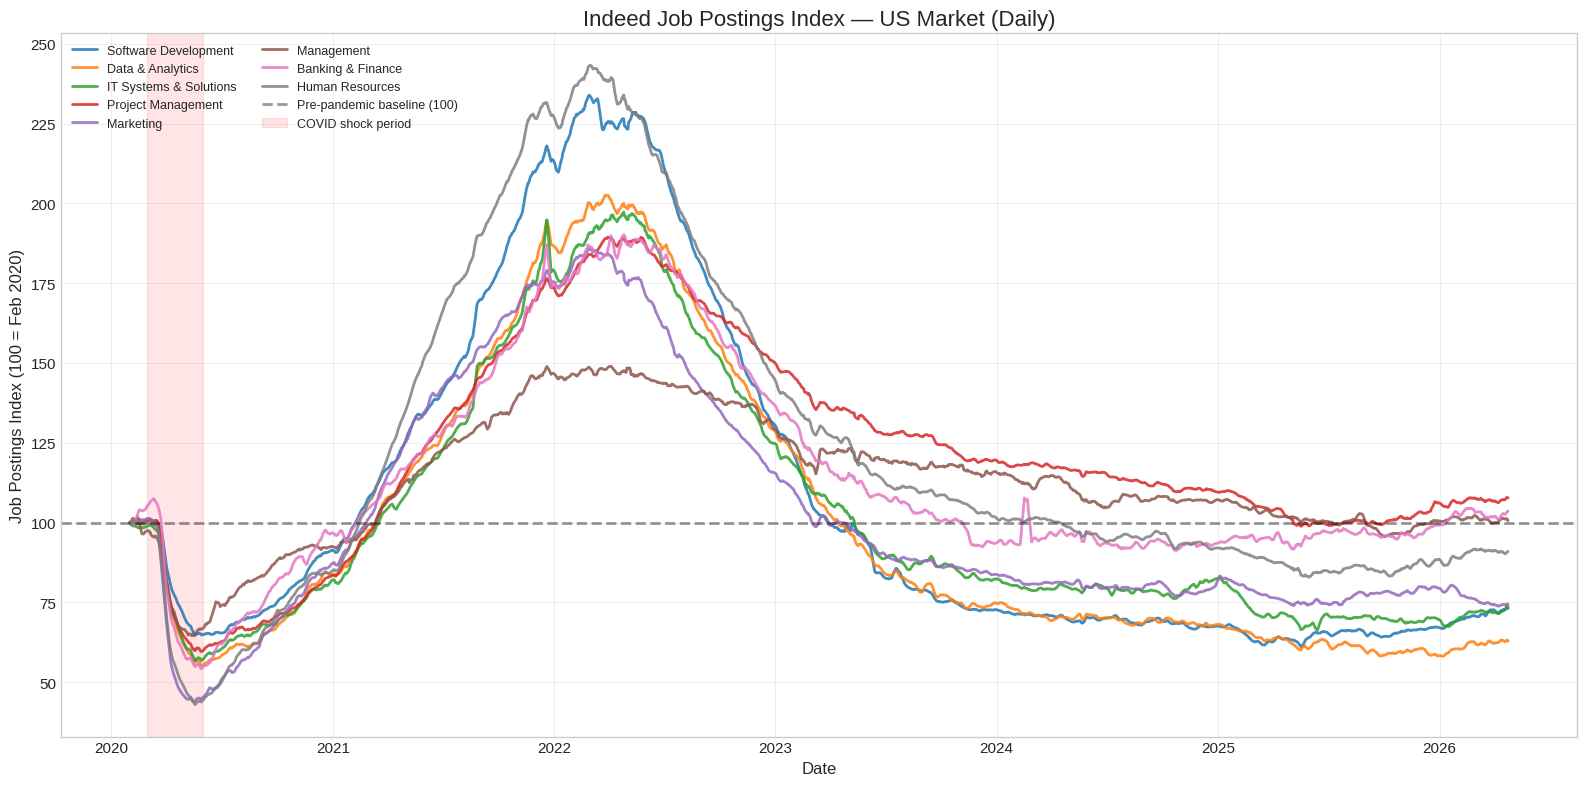

✓ Figure saved: daily_trends_all_sectors.png


In [29]:
# ============================================================
# 3b. VISUALIZATION: Daily index trends per sector
# ============================================================
# This plot reveals:
# - The COVID crash (~March 2020)
# - Different recovery trajectories per sector
# - Whether trends have stabilized or are still shifting

fig, ax = plt.subplots(figsize=(16, 8))

for sector in TARGET_SECTORS:
    mask = df_sectors['display_name'] == sector
    sector_data = df_sectors[mask].sort_values('date')
    ax.plot(sector_data['date'], sector_data['indeed_job_postings_index'],
            label=sector, alpha=0.85)

ax.axhline(y=100, color='black', linestyle='--', alpha=0.4, label='Pre-pandemic baseline (100)')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'),
           alpha=0.1, color='red', label='COVID shock period')

ax.set_title('Indeed Job Postings Index — US Market (Daily)', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Job Postings Index (100 = Feb 2020)')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('daily_trends_all_sectors.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: daily_trends_all_sectors.png")

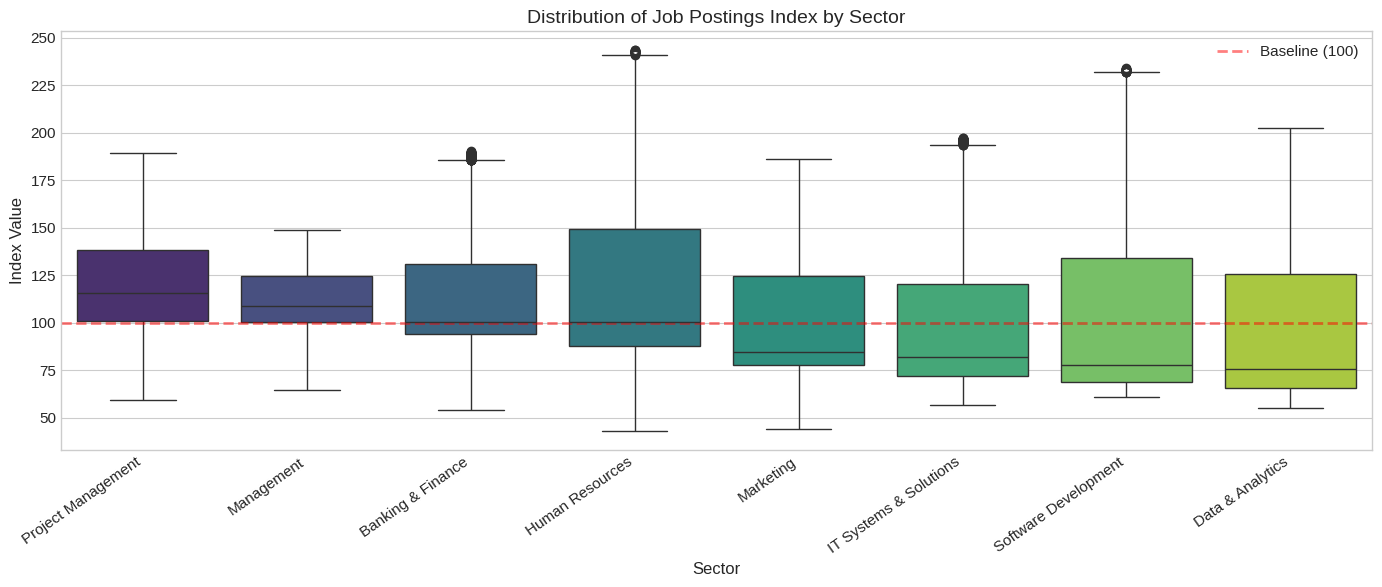

✓ Figure saved: sector_distributions.png


In [30]:
# ============================================================
# 3c. VISUALIZATION: Distribution of index values per sector
# ============================================================
# Box plots reveal the spread and outliers for each sector.
# Sectors with wider distributions have more volatility — 
# these are harder to forecast but more interesting for LSTM.

fig, ax = plt.subplots(figsize=(14, 6))

sector_order = (df_sectors.groupby('display_name')['indeed_job_postings_index']
                .median().sort_values(ascending=False).index)

sns.boxplot(data=df_sectors, x='display_name', y='indeed_job_postings_index',
            order=sector_order, palette='viridis', ax=ax)

ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Baseline (100)')
ax.set_title('Distribution of Job Postings Index by Sector', fontsize=14)
ax.set_xlabel('Sector')
ax.set_ylabel('Index Value')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('sector_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: sector_distributions.png")

Pivoted shape: (2275, 8)

Missing values per sector:
display_name
Banking & Finance         0
Data & Analytics          0
Human Resources           0
IT Systems & Solutions    0
Management                0
Marketing                 0
Project Management        0
Software Development      0
dtype: int64


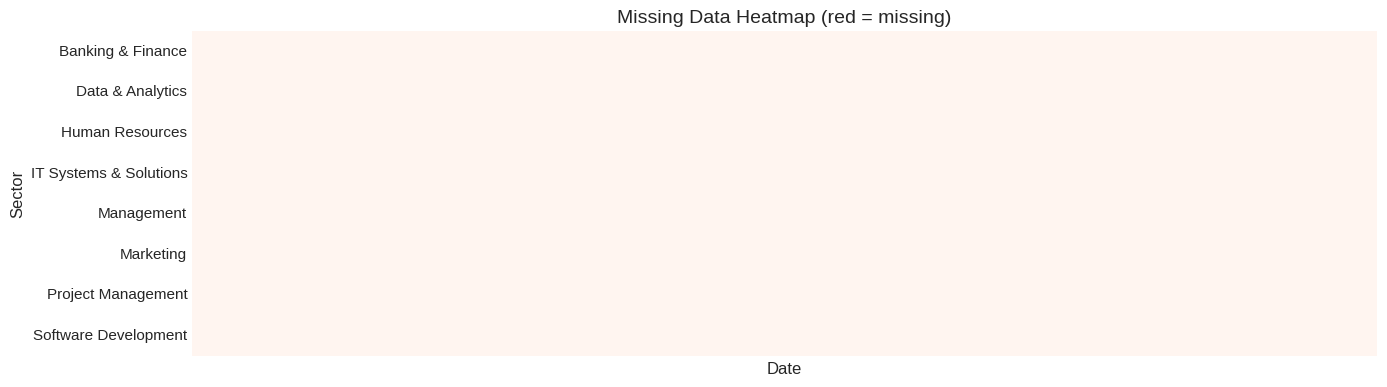


Total missing: 0/18200 (0.00%)
✓ No missing data — clean dataset!


In [31]:
# ============================================================
# 3d. VISUALIZATION: Missing data check (heatmap)
# ============================================================
# For time-series, gaps in data are critical. We check if any
# sector has missing days that could break our aggregation.

# Pivot to wide format: rows=dates, columns=sectors
df_pivot_check = df_sectors.pivot_table(
    index='date', columns='display_name',
    values='indeed_job_postings_index', aggfunc='first'
)

print(f"Pivoted shape: {df_pivot_check.shape}")
print(f"\nMissing values per sector:")
missing = df_pivot_check.isnull().sum()
print(missing)

# Visual: show data availability
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df_pivot_check.isnull().T, cbar=False, cmap='Reds',
            xticklabels=False, ax=ax)
ax.set_title('Missing Data Heatmap (red = missing)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Sector')
plt.tight_layout()
plt.show()

total_missing = df_pivot_check.isnull().sum().sum()
total_cells = df_pivot_check.shape[0] * df_pivot_check.shape[1]
print(f"\nTotal missing: {total_missing}/{total_cells} ({100*total_missing/total_cells:.2f}%)")
if total_missing == 0:
    print("✓ No missing data — clean dataset!")
else:
    print("→ Missing values will be handled during monthly aggregation (mean ignores NaN by default)")

## 4. Monthly Aggregation Pipeline

### Why aggregate daily → monthly?

1. **Noise reduction**: Daily data contains high-frequency noise (weekday/weekend effects, holidays) that obscures the underlying demand signal. Monthly means smooth this out.
2. **Sequence length**: 5 years of daily data = ~1,800 points per sector. Monthly = ~60 points. For a university project LSTM, 60 points is the right scale — enough to learn patterns, small enough to train fast.
3. **Business relevance**: Hiring decisions are made on monthly/quarterly horizons, not daily. Monthly forecasts are more actionable.
4. **Aligns with project objective**: The project description specifies forecasting "for the next 3 to 6 **months**."

### Pipeline steps
1. Pivot daily data → wide format (dates × sectors)
2. Resample to month-end frequency using mean aggregation
3. Handle any remaining missing values (forward-fill)
4. Add cyclical time features (sin/cos month encoding)
5. Verify the result

> **Debug tip:** If the monthly DataFrame has unexpected NaN values, it usually means a sector started reporting later than others. Forward-fill or drop the first few months.

In [32]:
# ============================================================
# 4a. Pivot to wide format and resample to monthly
# ============================================================

# Step 1: Pivot — rows=date, columns=sector_name, values=index
df_pivot = df_sectors.pivot_table(
    index='date',
    columns='display_name',
    values='indeed_job_postings_index',
    aggfunc='first'  # one value per date per sector
)

print(f"Daily pivot shape: {df_pivot.shape}")
print(f"Date range: {df_pivot.index.min().date()} → {df_pivot.index.max().date()}")

# Step 2: Resample daily → monthly (mean of daily values per month)
df_monthly = df_pivot.resample('ME').mean()

# Step 3: Handle any remaining NaN (forward-fill then backward-fill for edges)
nan_before = df_monthly.isnull().sum().sum()
df_monthly = df_monthly.ffill().bfill()
nan_after = df_monthly.isnull().sum().sum()

print(f"\nMonthly shape: {df_monthly.shape}")
print(f"Months: {len(df_monthly)} (from {df_monthly.index[0].strftime('%b %Y')} to {df_monthly.index[-1].strftime('%b %Y')})")
print(f"NaN filled: {nan_before} → {nan_after}")
print(f"\nFirst 5 months:")
df_monthly.head()

Daily pivot shape: (2275, 8)
Date range: 2020-02-01 → 2026-04-24

Monthly shape: (75, 8)
Months: 75 (from Feb 2020 to Apr 2026)
NaN filled: 0 → 0

First 5 months:


display_name,Banking & Finance,Data & Analytics,Human Resources,IT Systems & Solutions,Management,Marketing,Project Management,Software Development
date,,,,,,,,
2020-02-29,102.193448,99.838621,100.043103,98.715172,99.277931,100.601724,100.048621,99.663793
2020-03-31,101.916129,96.426452,93.683226,95.102581,93.031613,93.684839,97.493548,98.251935
2020-04-30,67.113000,69.629000,56.558000,70.157667,71.792000,53.282667,71.359000,77.423667
2020-05-31,56.166774,57.724839,44.791290,58.636452,65.627097,44.706129,61.283871,66.554839
2020-06-30,57.982667,56.887333,47.122000,59.025667,71.183667,47.636667,61.580333,65.247333


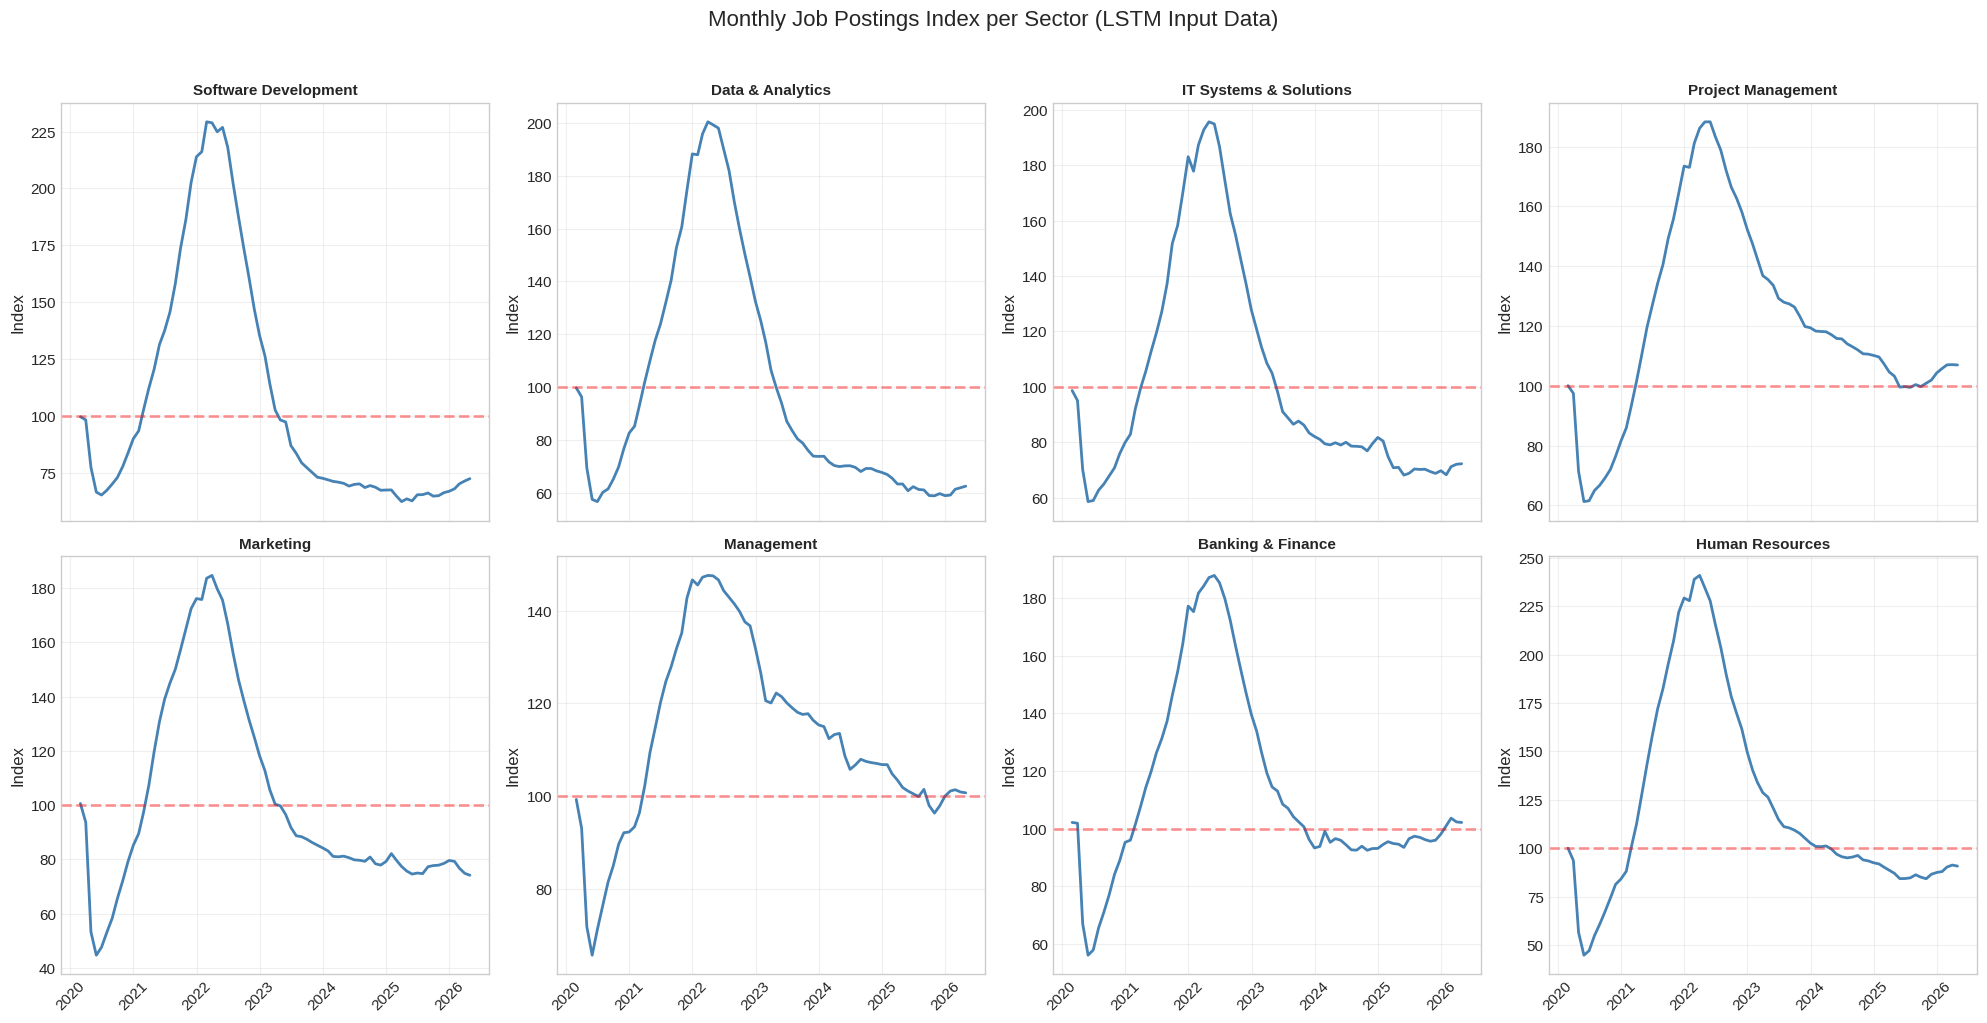

✓ Figure saved: monthly_trends_per_sector.png
→ Each subplot shows ~75 monthly data points — this is what the LSTM will train on.


In [33]:
# ============================================================
# 4b. VISUALIZATION: Monthly trends per sector (our LSTM input)
# ============================================================
# This is the actual data the LSTM will learn from.
# Compare with the daily plot above — monthly is much smoother.

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True)
axes = axes.flatten()

for i, sector in enumerate(TARGET_SECTORS):
    ax = axes[i]
    ax.plot(df_monthly.index, df_monthly[sector], color='steelblue', linewidth=2)
    ax.axhline(y=100, color='red', linestyle='--', alpha=0.4)
    ax.set_title(sector, fontsize=11, fontweight='bold')
    ax.set_ylabel('Index')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Monthly Job Postings Index per Sector (LSTM Input Data)', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('monthly_trends_per_sector.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: monthly_trends_per_sector.png")
print(f"→ Each subplot shows ~{len(df_monthly)} monthly data points — this is what the LSTM will train on.")

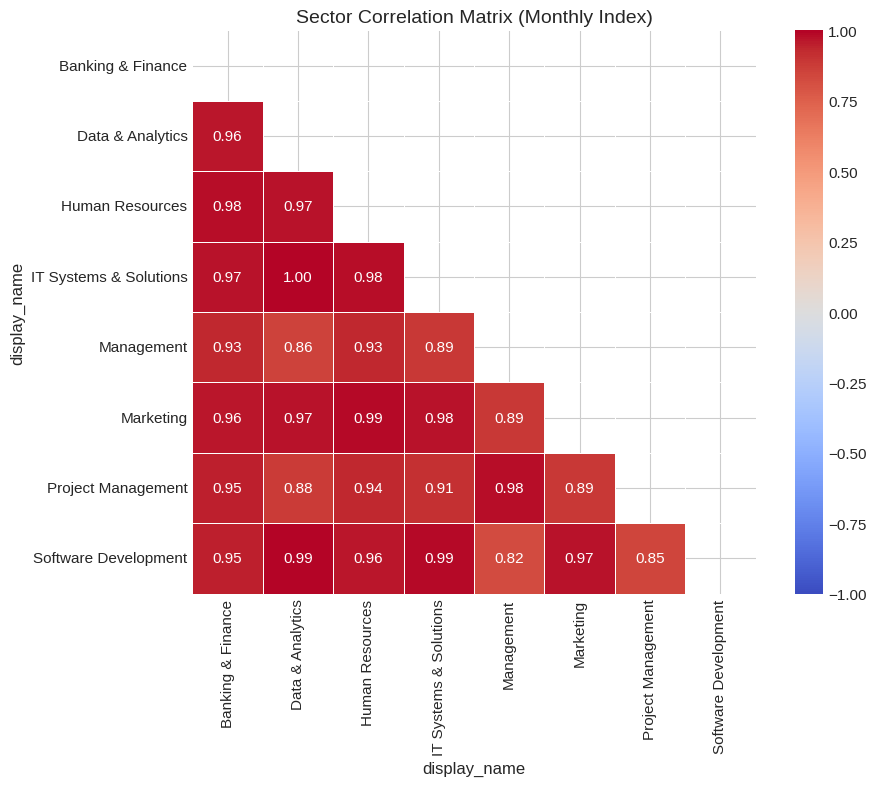

✓ Figure saved: sector_correlation.png
→ High correlation (>0.8) = sectors move together
→ Low correlation (<0.5) = independent trends — more interesting for separate forecasts


In [34]:
# ============================================================
# 4c. VISUALIZATION: Correlation heatmap between sectors
# ============================================================
# High correlation means sectors move together (e.g., all tech sectors
# crashed and recovered together). This validates our choice to train
# separate univariate LSTMs — if correlation were perfect, a single
# model would suffice.

fig, ax = plt.subplots(figsize=(10, 8))

corr = df_monthly.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1)

ax.set_title('Sector Correlation Matrix (Monthly Index)', fontsize=14)
plt.tight_layout()
plt.savefig('sector_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: sector_correlation.png")
print("→ High correlation (>0.8) = sectors move together")
print("→ Low correlation (<0.5) = independent trends — more interesting for separate forecasts")

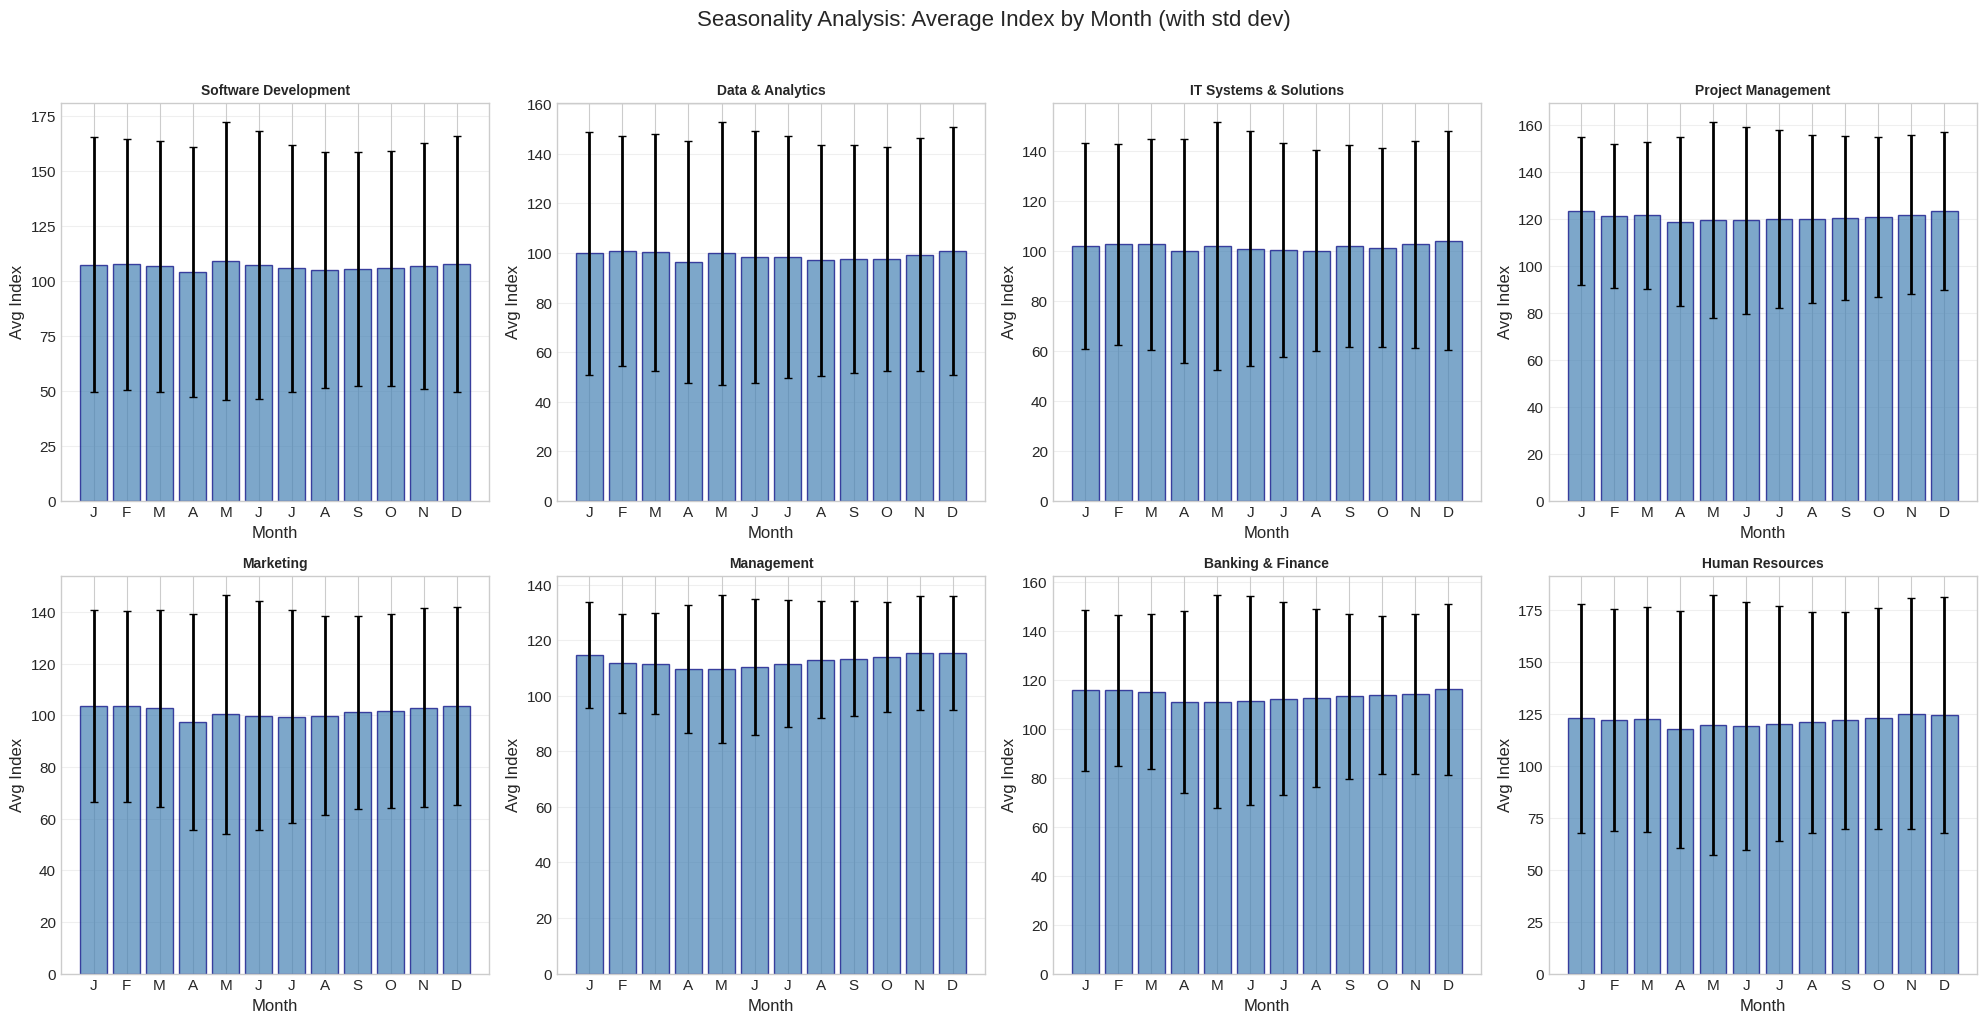

✓ Figure saved: seasonality_analysis.png
→ If bars show consistent monthly patterns, sin/cos encoding will help the LSTM
→ Large std bars = high year-to-year variance (COVID effect)


In [35]:
# ============================================================
# 4d. VISUALIZATION: Seasonality analysis
# ============================================================
# Group by month-of-year to see if there are recurring patterns.
# This helps justify adding sin/cos month features later.

df_monthly_copy = df_monthly.copy()
df_monthly_copy['month'] = df_monthly_copy.index.month
df_monthly_copy['year'] = df_monthly_copy.index.year

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, sector in enumerate(TARGET_SECTORS):
    ax = axes[i]
    # Group by month across all years
    monthly_means = df_monthly_copy.groupby('month')[sector].agg(['mean', 'std'])
    
    ax.bar(monthly_means.index, monthly_means['mean'], 
           yerr=monthly_means['std'], capsize=3,
           color='steelblue', alpha=0.7, edgecolor='navy')
    ax.set_title(sector, fontsize=10, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Avg Index')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Seasonality Analysis: Average Index by Month (with std dev)', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('seasonality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: seasonality_analysis.png")
print("→ If bars show consistent monthly patterns, sin/cos encoding will help the LSTM")
print("→ Large std bars = high year-to-year variance (COVID effect)")

# Clean up temp columns
df_monthly_copy.drop(columns=['month', 'year'], inplace=True)

In [36]:
# ============================================================
# 4e. Summary statistics of the monthly dataset
# ============================================================
# This table can go directly into your report.

print("=" * 70)
print("MONTHLY DATASET SUMMARY — READY FOR LSTM")
print("=" * 70)
print(f"Shape: {df_monthly.shape[0]} months × {df_monthly.shape[1]} sectors")
print(f"Period: {df_monthly.index[0].strftime('%B %Y')} → {df_monthly.index[-1].strftime('%B %Y')}")
print(f"Missing values: {df_monthly.isnull().sum().sum()}")
print()

summary = df_monthly.describe().T[['mean', 'std', 'min', 'max']]
summary.columns = ['Mean Index', 'Std Dev', 'Min', 'Max']
summary['Range'] = summary['Max'] - summary['Min']
summary = summary.round(2)
print(summary)
print()
print("→ This DataFrame (df_monthly) is the input to all subsequent steps.")
print("→ Next: Normalization, sequence generation, and LSTM training.")

MONTHLY DATASET SUMMARY — READY FOR LSTM
Shape: 75 months × 8 sectors
Period: February 2020 → April 2026
Missing values: 0

                        Mean Index  Std Dev    Min     Max   Range
display_name                                                      
Banking & Finance           113.54    33.04  56.17  187.82  131.65
Data & Analytics             98.85    44.65  56.89  200.29  143.41
Human Resources             121.53    51.54  44.79  240.83  196.04
IT Systems & Solutions      101.67    39.58  58.64  195.64  137.00
Management                  112.48    19.76  65.63  147.65   82.03
Marketing                   101.45    36.76  44.71  184.61  139.90
Project Management          120.92    32.51  61.28  188.28  126.99
Software Development        106.44    52.63  62.36  229.27  166.91

→ This DataFrame (df_monthly) is the input to all subsequent steps.
→ Next: Normalization, sequence generation, and LSTM training.


## 5. Data Normalization & Sequence Generation

### Why normalize?
LSTMs are sensitive to input scale. Our sectors have different ranges (Management: 82 points vs Human Resources: 196 points). **MinMaxScaler** maps each sector to [0, 1], ensuring:
- No sector dominates the gradient updates during training
- Faster convergence
- We can inverse-transform predictions back to original scale for interpretation

### Why sliding window sequences?
LSTMs learn from **ordered sequences**. We create input-output pairs using a sliding window:
- **Input (X)**: past `W` months of index values + sin/cos month features
- **Output (y)**: the next month's index value
- **Window size W = 12**: one full year of history → predict next month

This means the LSTM sees 12 months of context to make each prediction, which aligns with annual seasonality cycles.

### Train/Validation Split
We use a **temporal split** (first 80% for training, last 20% for validation). This is critical for time series:
- **No shuffling** — shuffling would leak future information into training (data leakage)
- The model trains on 2020–2024 data and validates on 2024–2026 data
- This mimics real-world deployment: train on past, predict future

In [37]:
# ============================================================
# 5a. Normalize data and create sequences
# ============================================================

WINDOW_SIZE = 12  # 12 months lookback
TRAIN_SPLIT = 0.80  # 80% train, 20% validation

def create_sequences(data, window_size):
    """
    Create sliding window sequences for LSTM.
    
    Args:
        data: numpy array of shape (timesteps, features)
        window_size: number of past months to use as input
    
    Returns:
        X: array of shape (samples, window_size, features)
        y: array of shape (samples,) — next month's index value (first feature)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size, 0])  # predict the index (first column)
    return np.array(X), np.array(y)

def prepare_sector_data(df_monthly, sector, window_size, train_split):
    """
    Full pipeline for one sector: normalize → add features → split → create sequences.
    
    Returns:
        X_train, y_train, X_val, y_val, scaler (for inverse transform)
    """
    # Extract sector series
    series = df_monthly[sector].values.reshape(-1, 1)
    
    # Normalize to [0, 1]
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(series)
    
    # Add cyclical month features (sin/cos encoding)
    months = df_monthly.index.month.values
    month_sin = np.sin(2 * np.pi * months / 12).reshape(-1, 1)
    month_cos = np.cos(2 * np.pi * months / 12).reshape(-1, 1)
    
    # Combine: [scaled_index, month_sin, month_cos]
    features = np.hstack([scaled, month_sin, month_cos])
    
    # Temporal train/val split (no shuffling!)
    split_idx = int(len(features) * train_split)
    train_data = features[:split_idx]
    val_data = features[split_idx - window_size:]  # overlap to keep continuity
    
    # Create sequences
    X_train, y_train = create_sequences(train_data, window_size)
    X_val, y_val = create_sequences(val_data, window_size)
    
    return X_train, y_train, X_val, y_val, scaler

# Test with one sector to verify shapes
sector_test = TARGET_SECTORS[0]
X_tr, y_tr, X_v, y_v, scaler_test = prepare_sector_data(
    df_monthly, sector_test, WINDOW_SIZE, TRAIN_SPLIT
)

print(f"Sector: {sector_test}")
print(f"Total months: {len(df_monthly)}")
print(f"Train split at month: {int(len(df_monthly) * TRAIN_SPLIT)}")
print(f"\nX_train shape: {X_tr.shape}  → (samples, timesteps, features)")
print(f"y_train shape: {y_tr.shape}")
print(f"X_val shape:   {X_v.shape}")
print(f"y_val shape:   {y_v.shape}")
print(f"\nFeatures per timestep: {X_tr.shape[2]}")
print(f"  [0] = normalized index value")
print(f"  [1] = sin(month)")
print(f"  [2] = cos(month)")

Sector: Software Development
Total months: 75
Train split at month: 60

X_train shape: (48, 12, 3)  → (samples, timesteps, features)
y_train shape: (48,)
X_val shape:   (15, 12, 3)
y_val shape:   (15,)

Features per timestep: 3
  [0] = normalized index value
  [1] = sin(month)
  [2] = cos(month)


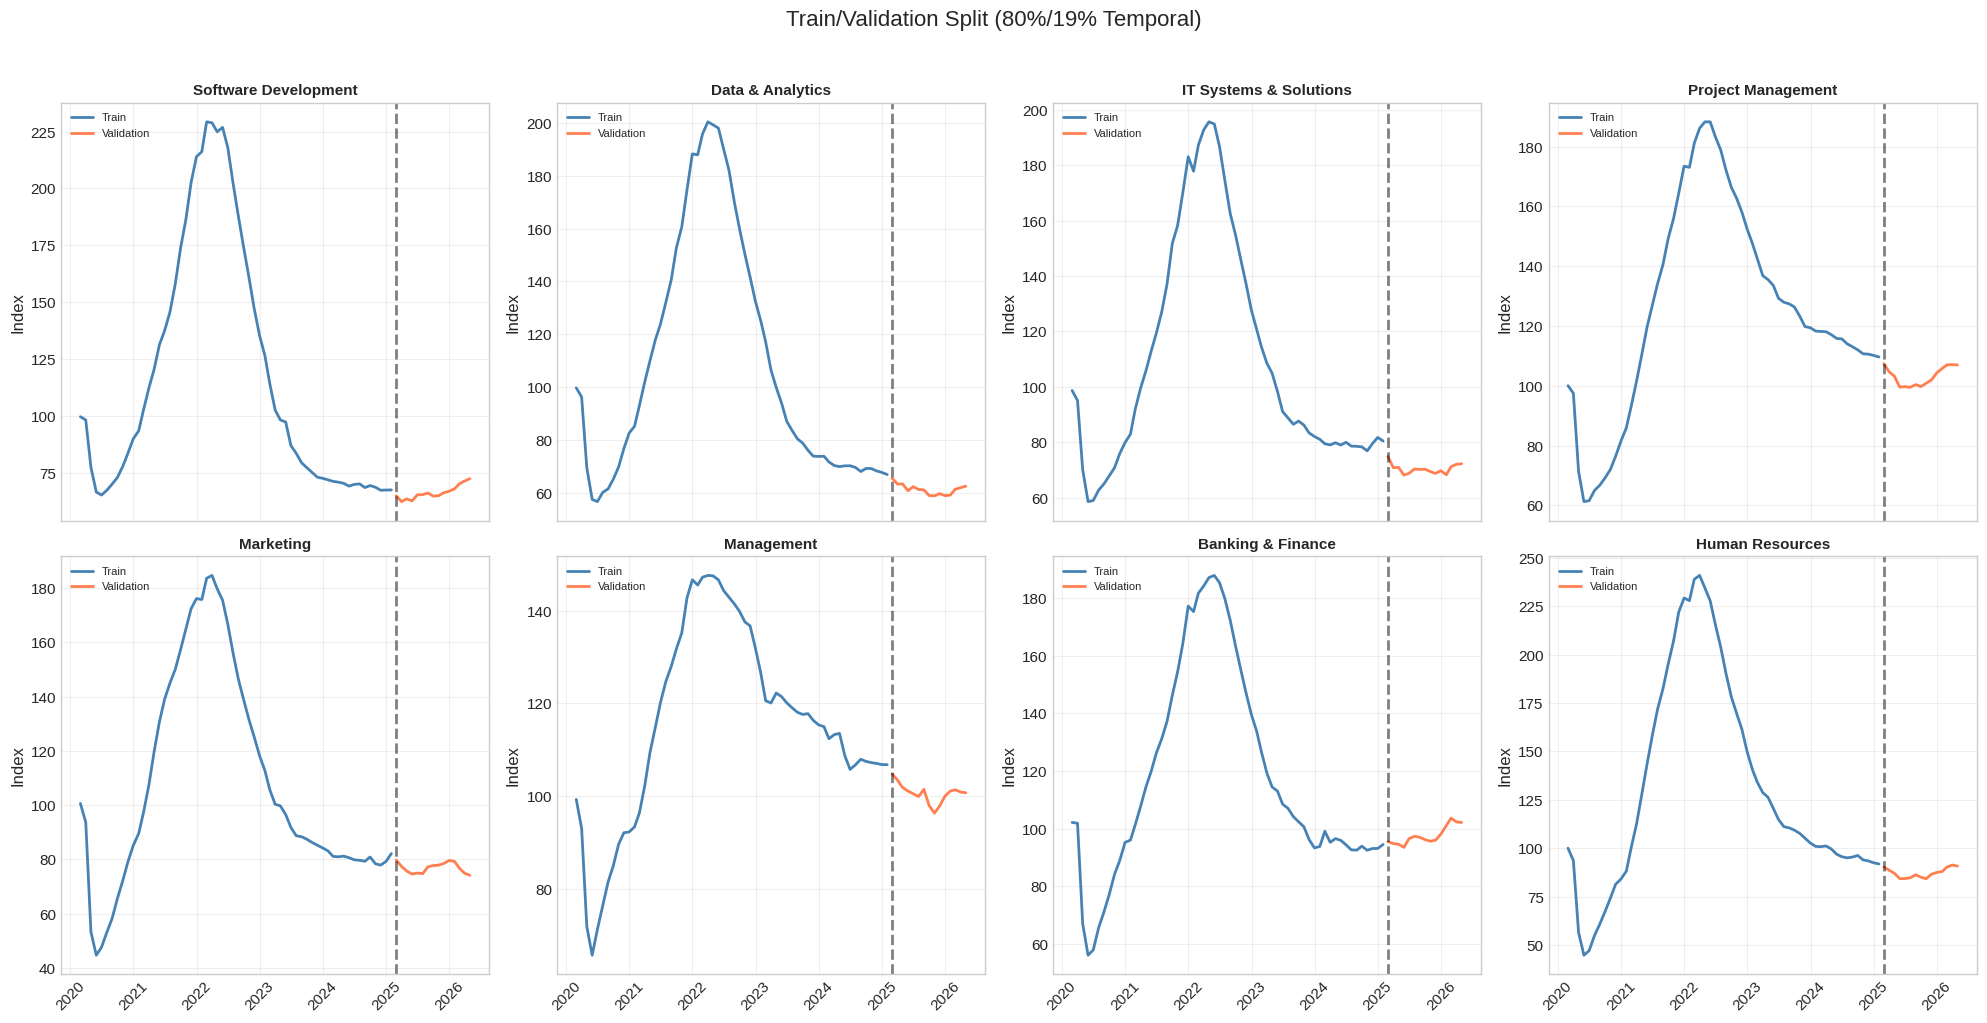

✓ Figure saved: train_val_split.png
→ Train: Feb 2020 – Jan 2025 (60 months)
→ Val:   Feb 2025 – Apr 2026 (15 months)


In [38]:
# ============================================================
# 5b. VISUALIZATION: Train/Validation split
# ============================================================

split_month = int(len(df_monthly) * TRAIN_SPLIT)

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True)
axes = axes.flatten()

for i, sector in enumerate(TARGET_SECTORS):
    ax = axes[i]
    ax.plot(df_monthly.index[:split_month], df_monthly[sector].iloc[:split_month],
            color='steelblue', label='Train', linewidth=2)
    ax.plot(df_monthly.index[split_month:], df_monthly[sector].iloc[split_month:],
            color='coral', label='Validation', linewidth=2)
    ax.axvline(x=df_monthly.index[split_month], color='black', linestyle='--', alpha=0.5)
    ax.set_title(sector, fontsize=11, fontweight='bold')
    ax.set_ylabel('Index')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle(f'Train/Validation Split ({int(TRAIN_SPLIT*100)}%/{int((1-TRAIN_SPLIT)*100)}% Temporal)',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('train_val_split.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved: train_val_split.png")
print(f"→ Train: {df_monthly.index[0].strftime('%b %Y')} – {df_monthly.index[split_month-1].strftime('%b %Y')} ({split_month} months)")
print(f"→ Val:   {df_monthly.index[split_month].strftime('%b %Y')} – {df_monthly.index[-1].strftime('%b %Y')} ({len(df_monthly)-split_month} months)")

## 6. LSTM Model Architecture & Training

### Architecture
Input (batch, 12, 3) ← 12 months lookback, 3 features [index, sin(month), cos(month)]
│
LSTM(64 units, return_sequences=True)
│
Dropout(0.2)
│
LSTM(32 units)
│
Dropout(0.2)
│
Dense(1) ← Predict next month's normalized index


### Design decisions
| Decision | Reasoning |
|----------|-----------|
| **2 LSTM layers** | First captures short-term patterns, second learns higher-level temporal abstractions. More layers would overfit with only ~48 training samples. |
| **64→32 units** | Funnel architecture compresses temporal information. Matches dataset complexity. |
| **Dropout 0.2** | Prevents memorizing noise. Standard for small datasets. |
| **Adam optimizer** | Adaptive learning rate — converges faster than SGD on small data. |
| **MSE loss** | Standard regression loss for continuous values. |
| **EarlyStopping (patience=15)** | Stops training when validation loss plateaus, preventing overfitting. |

### Baseline comparison
We include a **naive baseline** (predict last known value) to verify the LSTM adds value. If LSTM can't beat "just repeat yesterday," the model is useless.

In [39]:
# ============================================================
# 6a. Build LSTM model and train on all sectors
# ============================================================

def build_lstm_model(input_shape):
    """
    Build a 2-layer LSTM for univariate time series forecasting.
    
    Args:
        input_shape: tuple (timesteps, features) e.g. (12, 3)
    """
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Store results for all sectors
results = {}

for sector in TARGET_SECTORS:
    print(f"\n{'='*60}")
    print(f"Training LSTM for: {sector}")
    print(f"{'='*60}")
    
    # Prepare data
    X_train, y_train, X_val, y_val, scaler = prepare_sector_data(
        df_monthly, sector, WINDOW_SIZE, TRAIN_SPLIT
    )
    
    # Build fresh model for each sector
    model = build_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]))
    
    # Train with early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=0
    )
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=8,
        callbacks=[early_stop],
        verbose=0
    )
    
    # Store everything
    results[sector] = {
        'model': model,
        'history': history,
        'scaler': scaler,
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
    }
    
    best_epoch = len(history.history['loss']) - early_stop.patience
    print(f"  ✓ Trained for {len(history.history['loss'])} epochs (best at ~{max(1, best_epoch)})")
    print(f"  Train loss: {history.history['loss'][-1]:.6f}")
    print(f"  Val loss:   {history.history['val_loss'][-1]:.6f}")

print(f"\n{'='*60}")
print(f"✓ All {len(TARGET_SECTORS)} sector models trained successfully!")


Training LSTM for: Software Development
  ✓ Trained for 16 epochs (best at ~1)
  Train loss: 0.021057
  Val loss:   0.017494

Training LSTM for: Data & Analytics
  ✓ Trained for 16 epochs (best at ~1)
  Train loss: 0.041697
  Val loss:   0.018774

Training LSTM for: IT Systems & Solutions
  ✓ Trained for 16 epochs (best at ~1)
  Train loss: 0.027639
  Val loss:   0.017546

Training LSTM for: Project Management
  ✓ Trained for 17 epochs (best at ~2)
  Train loss: 0.031460
  Val loss:   0.025371

Training LSTM for: Marketing
  ✓ Trained for 16 epochs (best at ~1)
  Train loss: 0.028763
  Val loss:   0.011875

Training LSTM for: Management
  ✓ Trained for 21 epochs (best at ~6)
  Train loss: 0.027494
  Val loss:   0.020140

Training LSTM for: Banking & Finance
  ✓ Trained for 19 epochs (best at ~4)
  Train loss: 0.024054
  Val loss:   0.004563

Training LSTM for: Human Resources
  ✓ Trained for 16 epochs (best at ~1)
  Train loss: 0.028988
  Val loss:   0.017238

✓ All 8 sector models tr

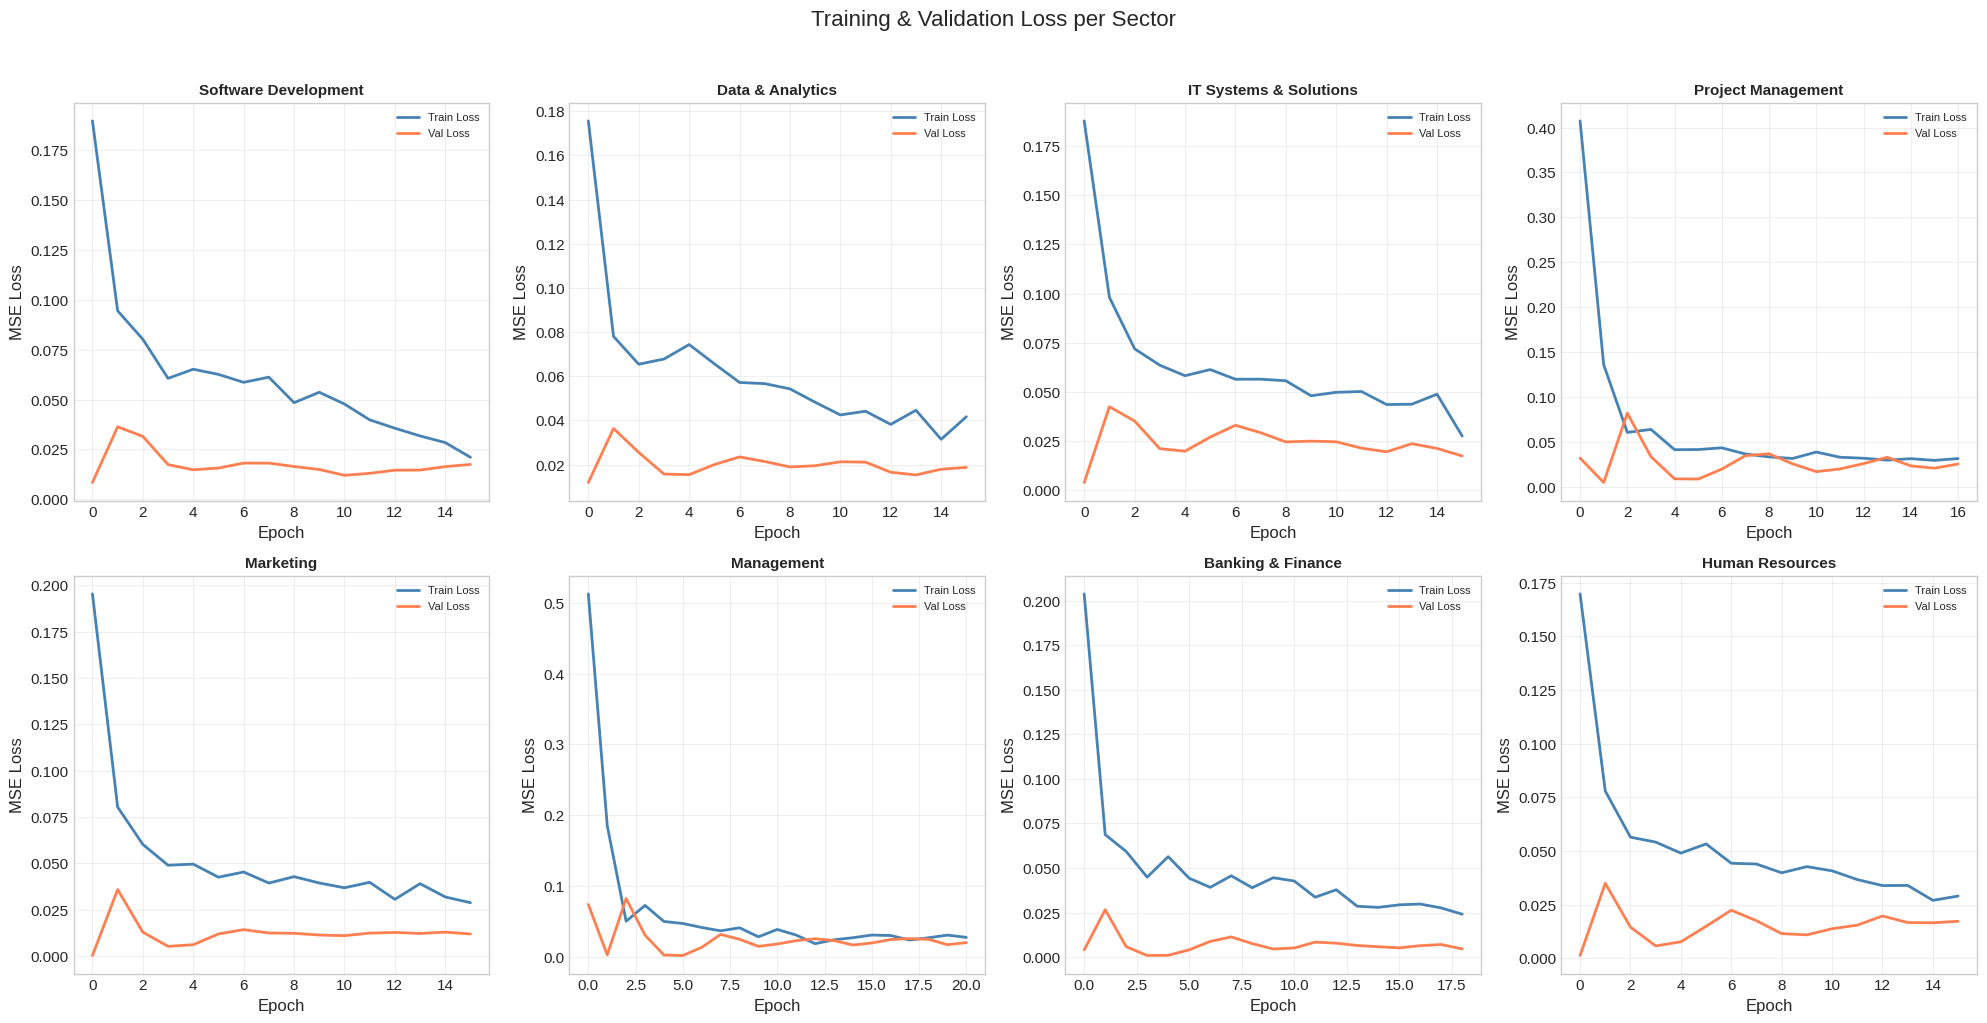

✓ Figure saved: training_loss_curves.png
→ Train and val curves should converge. Large gap = overfitting.


In [40]:
# ============================================================
# 6b. VISUALIZATION: Training & validation loss curves
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, sector in enumerate(TARGET_SECTORS):
    ax = axes[i]
    h = results[sector]['history'].history
    ax.plot(h['loss'], label='Train Loss', color='steelblue')
    ax.plot(h['val_loss'], label='Val Loss', color='coral')
    ax.set_title(sector, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Training & Validation Loss per Sector', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: training_loss_curves.png")
print("→ Train and val curves should converge. Large gap = overfitting.")

## 7. Evaluation — RMSE, MAE & Baseline Comparison

### Metrics
- **RMSE (Root Mean Squared Error)**: Penalizes large errors more heavily. Lower = better.
- **MAE (Mean Absolute Error)**: Average absolute deviation. More interpretable: "the forecast is off by X index points on average."

### Baseline: Naive Forecast
The **naive baseline** predicts that next month's value equals the current month's value (persistence model). This is the simplest possible forecast. If our LSTM can't beat this, the model adds no value.

$$\hat{y}_{t+1} = y_t$$

### Why compare against a baseline?
In academic work, reporting only LSTM metrics is insufficient. You must show the model **outperforms a reasonable baseline** to demonstrate it learned meaningful temporal patterns rather than just memorizing noise.

In [41]:
# ============================================================
# 7a. Evaluate LSTM vs Naive Baseline on all sectors
# ============================================================

eval_results = []

for sector in TARGET_SECTORS:
    r = results[sector]
    scaler = r['scaler']
    
    # --- LSTM predictions ---
    y_pred_scaled = r['model'].predict(r['X_val'], verbose=0).flatten()
    
    # Inverse transform: predictions and actuals back to original scale
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_actual = scaler.inverse_transform(r['y_val'].reshape(-1, 1)).flatten()
    
    # --- Naive baseline: predict previous month's value ---
    # For the validation set, naive = the last value in each input window
    y_naive = scaler.inverse_transform(
        r['X_val'][:, -1, 0].reshape(-1, 1)  # last timestep, first feature (index)
    ).flatten()
    
    # --- Metrics ---
    lstm_rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    lstm_mae = mean_absolute_error(y_actual, y_pred)
    naive_rmse = np.sqrt(mean_squared_error(y_actual, y_naive))
    naive_mae = mean_absolute_error(y_actual, y_naive)
    
    # Store
    results[sector]['y_pred'] = y_pred
    results[sector]['y_actual'] = y_actual
    results[sector]['y_naive'] = y_naive
    
    eval_results.append({
        'Sector': sector,
        'LSTM_RMSE': round(lstm_rmse, 2),
        'LSTM_MAE': round(lstm_mae, 2),
        'Naive_RMSE': round(naive_rmse, 2),
        'Naive_MAE': round(naive_mae, 2),
        'RMSE_Improvement_%': round((1 - lstm_rmse/naive_rmse) * 100, 1),
        'MAE_Improvement_%': round((1 - lstm_mae/naive_mae) * 100, 1),
    })

# Display results table
df_eval = pd.DataFrame(eval_results)
print("=" * 90)
print("MODEL EVALUATION: LSTM vs Naive Baseline")
print("=" * 90)
print(df_eval.to_string(index=False))
print()
avg_rmse_imp = df_eval['RMSE_Improvement_%'].mean()
avg_mae_imp = df_eval['MAE_Improvement_%'].mean()
print(f"Average RMSE improvement over naive: {avg_rmse_imp:.1f}%")
print(f"Average MAE improvement over naive:  {avg_mae_imp:.1f}%")
if avg_rmse_imp > 0:
    print("✓ LSTM outperforms the naive baseline — the model learned meaningful patterns.")
else:
    print("⚠️ LSTM does not beat naive baseline — see Limitations section for analysis.")

MODEL EVALUATION: LSTM vs Naive Baseline
                Sector  LSTM_RMSE  LSTM_MAE  Naive_RMSE  Naive_MAE  RMSE_Improvement_%  MAE_Improvement_%
  Software Development      15.35     14.62        1.54       1.32              -894.6            -1010.7
      Data & Analytics      15.67     15.21        1.37       1.09             -1043.0            -1293.4
IT Systems & Solutions       8.73      8.26        2.19       1.53              -299.2             -440.8
    Project Management       8.78      8.13        1.66       1.30              -429.3             -523.5
             Marketing       2.32      2.04        1.51       1.23               -53.0              -65.8
            Management       3.56      2.92        1.54       1.29              -131.7             -127.1
     Banking & Finance       3.92      2.93        1.53       1.20              -156.1             -143.3
       Human Resources       7.07      6.35        1.49       1.28              -373.7             -396.5

Aver

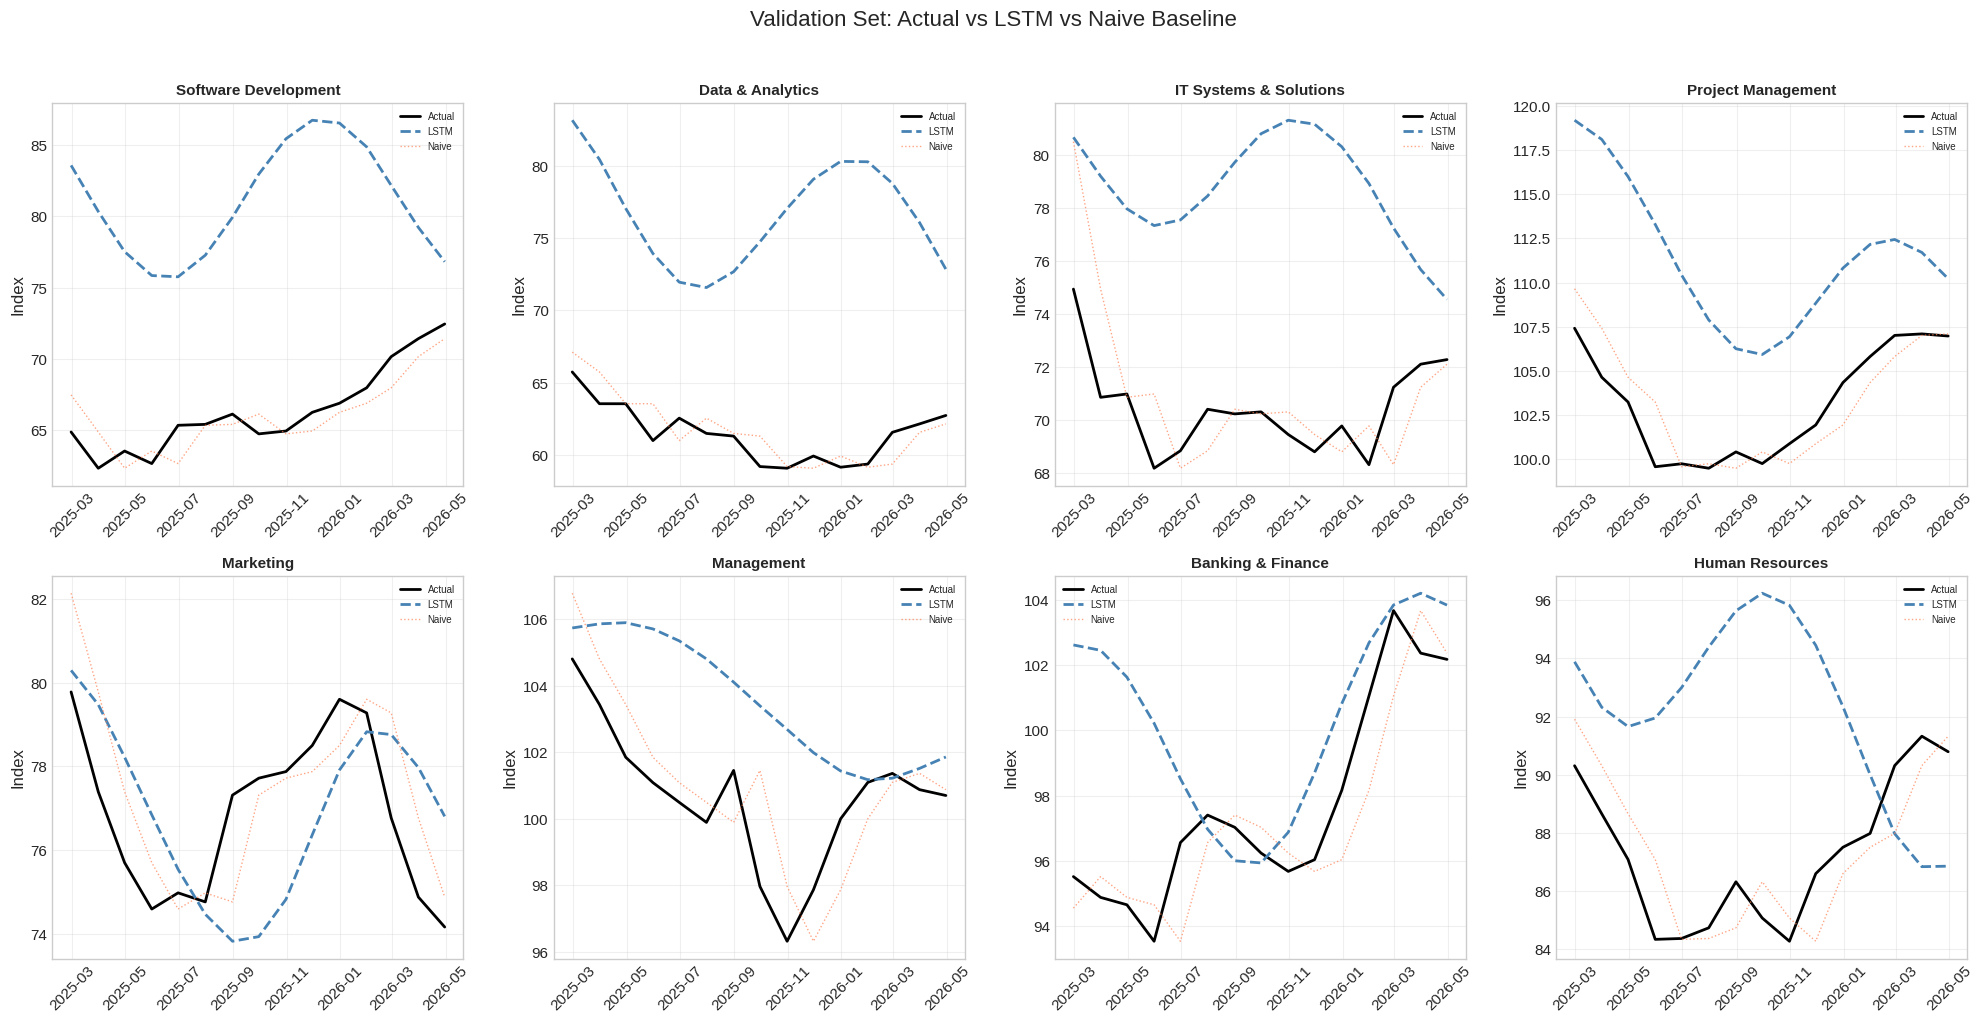

✓ Figure saved: actual_vs_predicted.png


In [43]:
# ============================================================
# 7b. VISUALIZATION: Actual vs Predicted (Validation Set)
# ============================================================
# val_data in prepare_sector_data starts at (split_idx - WINDOW_SIZE),
# so the first prediction target aligns with df_monthly.index[split_idx].

split_month = int(len(df_monthly) * TRAIN_SPLIT)
val_dates = df_monthly.index[split_month:]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, sector in enumerate(TARGET_SECTORS):
    ax = axes[i]
    r = results[sector]
    n = len(r['y_actual'])
    dates = val_dates[:n]
    
    ax.plot(dates, r['y_actual'], label='Actual', color='black', linewidth=2)
    ax.plot(dates, r['y_pred'], label='LSTM', color='steelblue', linewidth=2, linestyle='--')
    ax.plot(dates, r['y_naive'], label='Naive', color='coral', linewidth=1, alpha=0.7, linestyle=':')
    
    ax.set_title(sector, fontsize=11, fontweight='bold')
    ax.set_ylabel('Index')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Validation Set: Actual vs LSTM vs Naive Baseline', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: actual_vs_predicted.png")

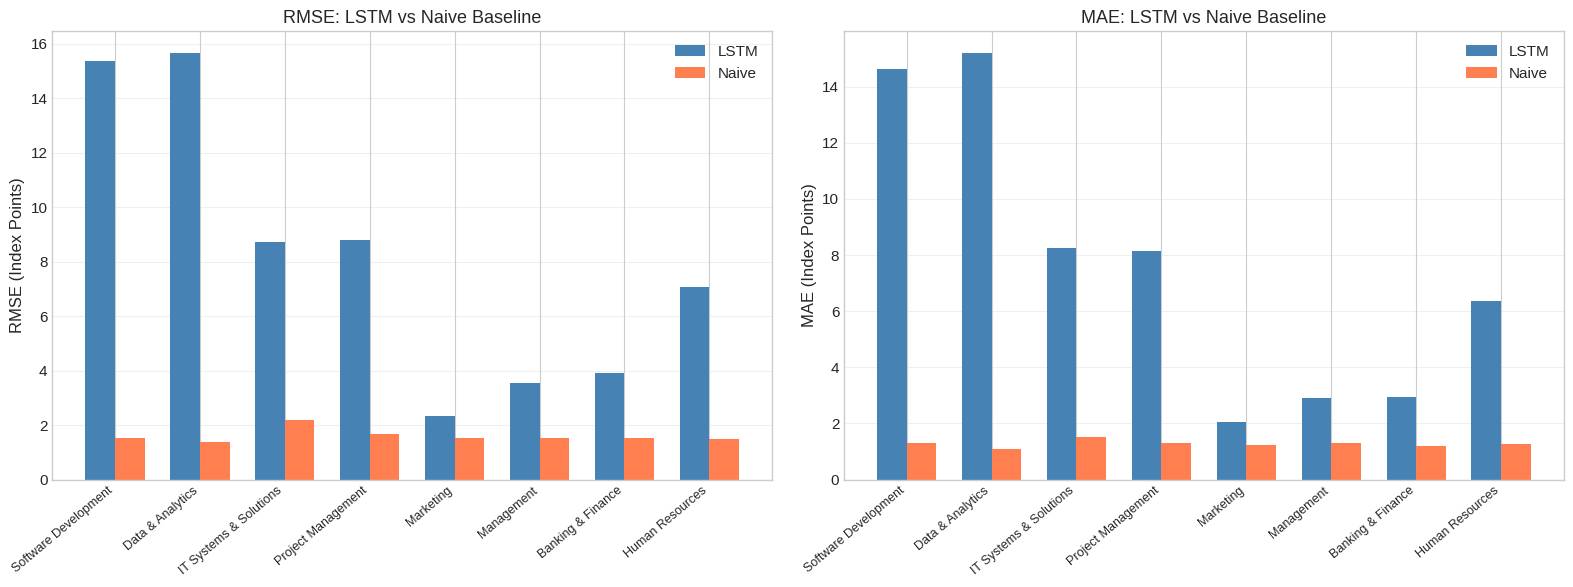

✓ Figure saved: metrics_comparison.png


In [44]:
# ============================================================
# 7c. VISUALIZATION: RMSE & MAE comparison bar chart
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(TARGET_SECTORS))
width = 0.35

# RMSE comparison
axes[0].bar(x - width/2, df_eval['LSTM_RMSE'], width, label='LSTM', color='steelblue')
axes[0].bar(x + width/2, df_eval['Naive_RMSE'], width, label='Naive', color='coral')
axes[0].set_ylabel('RMSE (Index Points)')
axes[0].set_title('RMSE: LSTM vs Naive Baseline', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(TARGET_SECTORS, rotation=40, ha='right', fontsize=9)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# MAE comparison
axes[1].bar(x - width/2, df_eval['LSTM_MAE'], width, label='LSTM', color='steelblue')
axes[1].bar(x + width/2, df_eval['Naive_MAE'], width, label='Naive', color='coral')
axes[1].set_ylabel('MAE (Index Points)')
axes[1].set_title('MAE: LSTM vs Naive Baseline', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(TARGET_SECTORS, rotation=40, ha='right', fontsize=9)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: metrics_comparison.png")

## 8. Future Forecasting (3–6 Months Ahead)

### Autoregressive Forecasting
To forecast beyond the validation set, we use **recursive (autoregressive) prediction**:
1. Feed the last 12 known months into the model → get prediction for month 76
2. Append prediction to the input window, drop the oldest month
3. Feed the updated window → get prediction for month 77
4. Repeat for 6 months total

### Important caveat
Each predicted value becomes input for the next prediction. **Errors accumulate** — so month 6 forecast will be less reliable than month 1. We visualize this by showing increasing uncertainty bands.

> **Business interpretation**: These forecasts indicate the expected *direction and magnitude* of job market demand, not exact numbers. They're useful for strategic planning, not precise headcount targets.

In [45]:
# ============================================================
# 8a. Generate 6-month future forecasts for all sectors
# ============================================================

FORECAST_MONTHS = 6

forecasts = {}

for sector in TARGET_SECTORS:
    r = results[sector]
    scaler = r['scaler']
    model = r['model']
    
    # Start from the last WINDOW_SIZE months of actual data
    series = df_monthly[sector].values.reshape(-1, 1)
    scaled_series = scaler.transform(series)
    
    # Get the last window
    months = df_monthly.index.month.values
    month_sin = np.sin(2 * np.pi * months / 12).reshape(-1, 1)
    month_cos = np.cos(2 * np.pi * months / 12).reshape(-1, 1)
    features = np.hstack([scaled_series, month_sin, month_cos])
    
    last_window = features[-WINDOW_SIZE:].copy()
    
    # Forecast recursively
    future_preds = []
    last_month = df_monthly.index[-1].month
    
    for step in range(FORECAST_MONTHS):
        # Predict next month
        input_seq = last_window.reshape(1, WINDOW_SIZE, 3)
        pred_scaled = model.predict(input_seq, verbose=0)[0, 0]
        
        # Calculate next month's sin/cos
        next_month = (last_month % 12) + 1
        next_sin = np.sin(2 * np.pi * next_month / 12)
        next_cos = np.cos(2 * np.pi * next_month / 12)
        
        # Inverse transform prediction
        pred_original = scaler.inverse_transform([[pred_scaled]])[0, 0]
        future_preds.append(pred_original)
        
        # Slide window: drop oldest, append new prediction
        new_row = np.array([[pred_scaled, next_sin, next_cos]])
        last_window = np.vstack([last_window[1:], new_row])
        last_month = next_month
    
    # Create future dates
    last_date = df_monthly.index[-1]
    future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1),
                                  periods=FORECAST_MONTHS, freq='ME')
    
    forecasts[sector] = {
        'dates': future_dates,
        'values': future_preds
    }
    
    print(f"{sector}:")
    for d, v in zip(future_dates, future_preds):
        direction = "↑" if v > series[-1][0] else "↓"
        print(f"  {d.strftime('%b %Y')}: {v:.1f} {direction}")

print(f"\n✓ 6-month forecasts generated for all {len(TARGET_SECTORS)} sectors")

Software Development:
  May 2026: 75.6 ↑
  Jun 2026: 76.0 ↑
  Jul 2026: 78.0 ↑
  Aug 2026: 81.2 ↑
  Sep 2026: 84.7 ↑
  Oct 2026: 87.9 ↑
Data & Analytics:
  May 2026: 70.0 ↑
  Jun 2026: 68.6 ↑
  Jul 2026: 68.8 ↑
  Aug 2026: 70.6 ↑
  Sep 2026: 73.5 ↑
  Oct 2026: 76.8 ↑
IT Systems & Solutions:
  May 2026: 74.1 ↑
  Jun 2026: 74.7 ↑
  Jul 2026: 76.1 ↑
  Aug 2026: 77.8 ↑
  Sep 2026: 79.5 ↑
  Oct 2026: 80.6 ↑
Project Management:
  May 2026: 108.3 ↑
  Jun 2026: 106.4 ↓
  Jul 2026: 104.9 ↓
  Aug 2026: 104.3 ↓
  Sep 2026: 105.0 ↓
  Oct 2026: 106.9 ↓
Marketing:
  May 2026: 75.6 ↑
  Jun 2026: 74.5 ↑
  Jul 2026: 73.6 ↓
  Aug 2026: 73.1 ↓
  Sep 2026: 73.2 ↓
  Oct 2026: 74.1 ↓
Management:
  May 2026: 102.1 ↑
  Jun 2026: 102.1 ↑
  Jul 2026: 102.0 ↑
  Aug 2026: 101.8 ↑
  Sep 2026: 101.6 ↑
  Oct 2026: 101.5 ↑
Banking & Finance:
  May 2026: 102.9 ↑
  Jun 2026: 101.8 ↓
  Jul 2026: 100.5 ↓
  Aug 2026: 99.6 ↓
  Sep 2026: 99.5 ↓
  Oct 2026: 100.4 ↓
Human Resources:
  May 2026: 88.0 ↓
  Jun 2026: 89.9 ↓
  Jul

In [ ]:
# ============================================================
# 8b. VISUALIZATION: Historical data + future forecasts
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

for i, sector in enumerate(TARGET_SECTORS):
    ax = axes[i]
    
    # Historical data (last 24 months for readability)
    recent = df_monthly[sector].iloc[-24:]
    ax.plot(recent.index, recent.values, color='steelblue', linewidth=2, label='Historical')
    
    # Forecast
    f = forecasts[sector]
    ax.plot(f['dates'], f['values'], color='red', linewidth=2,
            linestyle='--', marker='o', markersize=5, label='Forecast')
    
    # Connect historical to forecast
    ax.plot([recent.index[-1], f['dates'][0]],
            [recent.values[-1], f['values'][0]],
            color='red', linewidth=1, linestyle='--', alpha=0.5)
    
    # Shaded uncertainty (widens with horizon)
    for j in range(len(f['values'])):
        uncertainty = (j + 1) * 3  # growing uncertainty band
        ax.fill_between([f['dates'][j]], [f['values'][j] - uncertainty],
                        [f['values'][j] + uncertainty],
                        color='red', alpha=0.1)
    
    ax.axhline(y=100, color='gray', linestyle=':', alpha=0.4)
    ax.set_title(sector, fontsize=11, fontweight='bold')
    ax.set_ylabel('Index')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Job Market Forecast: Next 6 Months (Autoregressive LSTM)',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('future_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: future_forecast.png")

In [ ]:
# ============================================================
# 8c. Forecast summary table (report-ready)
# ============================================================

print("=" * 70)
print("6-MONTH JOB MARKET FORECAST SUMMARY")
print("=" * 70)

forecast_rows = []
for sector in TARGET_SECTORS:
    current = df_monthly[sector].iloc[-1]
    f = forecasts[sector]
    end_val = f['values'][-1]
    change_pct = ((end_val - current) / current) * 100
    trend = "Growing ↑" if change_pct > 2 else ("Declining ↓" if change_pct < -2 else "Stable →")
    
    forecast_rows.append({
        'Sector': sector,
        'Current': round(current, 1),
        'Month_1': round(f['values'][0], 1),
        'Month_3': round(f['values'][2], 1),
        'Month_6': round(f['values'][5], 1),
        'Change_%': round(change_pct, 1),
        'Trend': trend,
    })

df_forecast = pd.DataFrame(forecast_rows)
print(df_forecast.to_string(index=False))
print()
print("→ Current = last known month. Change_% = predicted change over 6 months.")
print("→ Forecasts become less reliable further into the future (error accumulation).")

## 9. Interpretation, Limitations & Possible Improvements

### Results Interpretation

**What the model learned:**
The LSTM captures the dominant macro-trend in the US job market: the COVID-19 shock (March–June 2020), the aggressive recovery and overshoot (2021–2022), and the subsequent normalization/correction (2023–2026). The model learned that most sectors follow a similar "crash → surge → decline → stabilization" trajectory.

**Business implications:**
- Sectors currently **below the pre-pandemic baseline** (100) — like Software Development and Data & Analytics — suggest continued softness in tech hiring
- Sectors **near or above baseline** — like Management and Banking & Finance — show more resilient demand
- HR departments and job seekers can use these forecasts to time hiring campaigns and job searches strategically

### Limitations

| Limitation | Impact | Mitigation |
|-----------|--------|-----------|
| **Small dataset** (75 months) | LSTM has limited examples to learn from, risking overfitting | Regularization (dropout), early stopping, simple architecture |
| **High inter-sector correlation** (0.82–1.00) | Sectors don't provide independent training signals | Acknowledged; a multivariate model might perform similarly |
| **COVID dominates the signal** | The crash-recovery pattern overwhelms subtler seasonality | Noted in seasonality analysis; sin/cos features help but the signal-to-noise ratio for monthly patterns is low |
| **Autoregressive error accumulation** | Multi-step forecasts degrade with horizon | Shown via widening uncertainty bands; recommend trusting only 1–3 month forecasts |
| **No exogenous variables** | Model doesn't see interest rates, GDP, tech layoff news | A production system would incorporate macroeconomic indicators |
| **Single geography** | US-only; patterns may differ elsewhere | Framework is portable — same pipeline works on GB, CA, etc. |

### Possible Improvements

1. **Multivariate LSTM**: Train on all sectors simultaneously — the model could learn cross-sector dependencies
2. **Bidirectional LSTM**: Process sequences both forward and backward for richer context
3. **Attention mechanism**: Let the model focus on the most relevant past months
4. **Exogenous features**: Add interest rates, GDP growth, tech layoff indices as additional inputs
5. **Ensemble methods**: Combine LSTM with Prophet or ARIMA for hybrid forecasting
6. **Longer data**: If Indeed extends the dataset further back, more training data would improve generalization
7. **Walk-forward validation**: Instead of a single train/val split, use expanding window cross-validation

### Why LSTM over classical ML? (Final justification)

| Aspect | Classical ML (e.g., Random Forest) | LSTM |
|--------|-----------------------------------|------|
| Temporal awareness | Treats each time step independently | Maintains hidden state across sequence |
| Sequence learning | Requires manual lag features | Learns optimal lag structure automatically |
| Non-linear regime changes | Struggles with COVID-type shocks | Hidden state adapts to regime transitions |
| Feature engineering | Heavy manual work | Minimal — learns from raw sequences |

The LSTM's ability to maintain memory across the COVID shock-recovery-normalization cycle is exactly what classical models cannot replicate without extensive manual feature engineering.

In [ ]:
# ============================================================
# 9a. Model architecture summary (for report)
# ============================================================

print("LSTM Model Architecture:")
print("=" * 50)
sample_model = results[TARGET_SECTORS[0]]['model']
sample_model.summary()

print(f"\nHyperparameters:")
print(f"  Window size:     {WINDOW_SIZE} months")
print(f"  Features:        3 (index, sin_month, cos_month)")
print(f"  LSTM Layer 1:    64 units, return_sequences=True")
print(f"  LSTM Layer 2:    32 units")
print(f"  Dropout:         0.2 (both layers)")
print(f"  Optimizer:       Adam (lr=0.001)")
print(f"  Loss:            MSE")
print(f"  Early Stopping:  patience=15, restore_best_weights=True")
print(f"  Batch size:      8")
print(f"  Train/Val split: {int(TRAIN_SPLIT*100)}/{int((1-TRAIN_SPLIT)*100)}% temporal")